In [206]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import lissa as li

from sktime.transformations.series.vmd import VmdTransformer
from scipy.signal import hilbert

import matplotlib.dates as mdates
from matplotlib.collections import LineCollection

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)

Headers = [
    "ESP Vibration X",
    "ESP Vibration Y",
    ]

número de bombas: 38
número de runs: 57


In [220]:
pump = pumpList[10]
print(pump)
entirePumpData = entireData.groupby("Well Run").get_group(pump)
pumpData = entirePumpData[Headers]

testData = (entirePumpData.groupby("Well_down")[Headers]
 .apply(lambda x: x.ewm(span=8).mean()-x.expanding().mean())
 .reset_index()
 .set_index("time")
 .drop(columns="Well_down")
 .sort_index())

A-28 1


In [216]:
# pumpData.hist(bins=40,figsize=(20,5))
# pumpData.diff().hist(bins=50,figsize=(20,5))
# pumpData.diff().plot(figsize=(20,5))
# plt.figure()
# pumpData.pow(2).sum(axis=1).diff().hist(bins=50,figsize=(20,5))
# pumpData = entireData.groupby("Well Run").get_group("B-10 1")[Headers]
# plt.figure()
# plt.scatter(pumpData["ESP Vibration X"].diff(),pumpData["ESP Vibration Y"].diff())

def plot_multicolored(ax, x, y, c):

    if isinstance(x, pd.DatetimeIndex):
        x_n = (x - x[0]).total_seconds()
    points = np.array([x_n, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Criar LineCollection com colormap
    lc = LineCollection(segments, cmap='jet', norm=plt.Normalize(c.min(), c.max()))
    lc.set_array(c)
    lc.set_linewidth(2)
    
    ax.add_collection(lc)
    ax.autoscale()


/tmp/ipykernel_134577/348143510.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


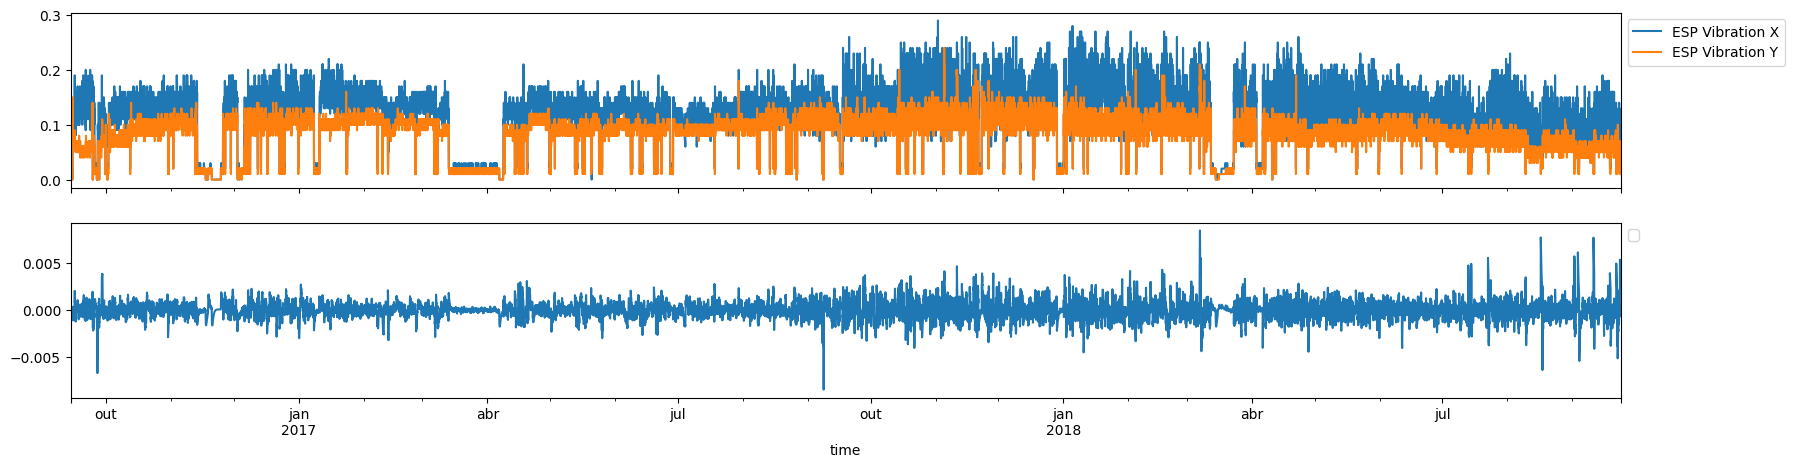

In [243]:
vmdModel = VmdTransformer(K=4,returned_decomp="u")
#prop = "ESP discharge pressure"

data = testData.diff().ewm(span=24).mean().sum(axis=1)

test = vmdModel.fit_transform(data)

test.index = data.index

h = hilbert(test)
instantAngle = pd.DataFrame(np.angle(h),index=data.index).diff().fillna(0)

fig,axs = plt.subplots(2,1)


pumpData.plot(ax=axs[0],sharex=True)

data.plot(ax=axs[1],figsize=(20,5),legend="yes")
axs[0].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

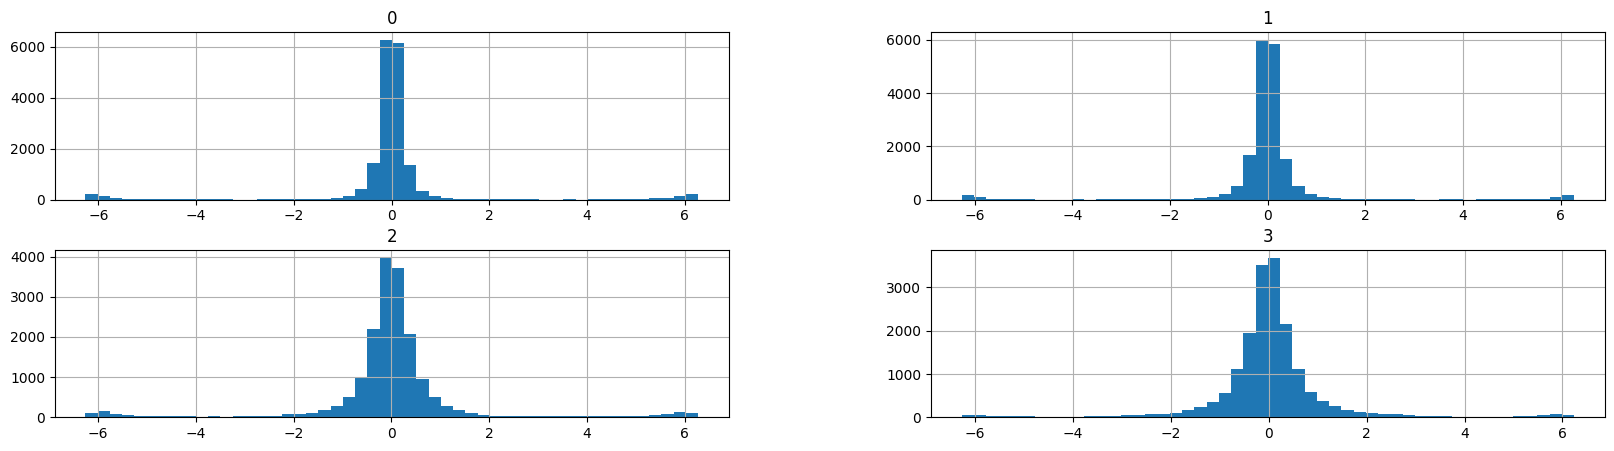

In [251]:
instantAngle.hist(bins=50,figsize=(20,5))

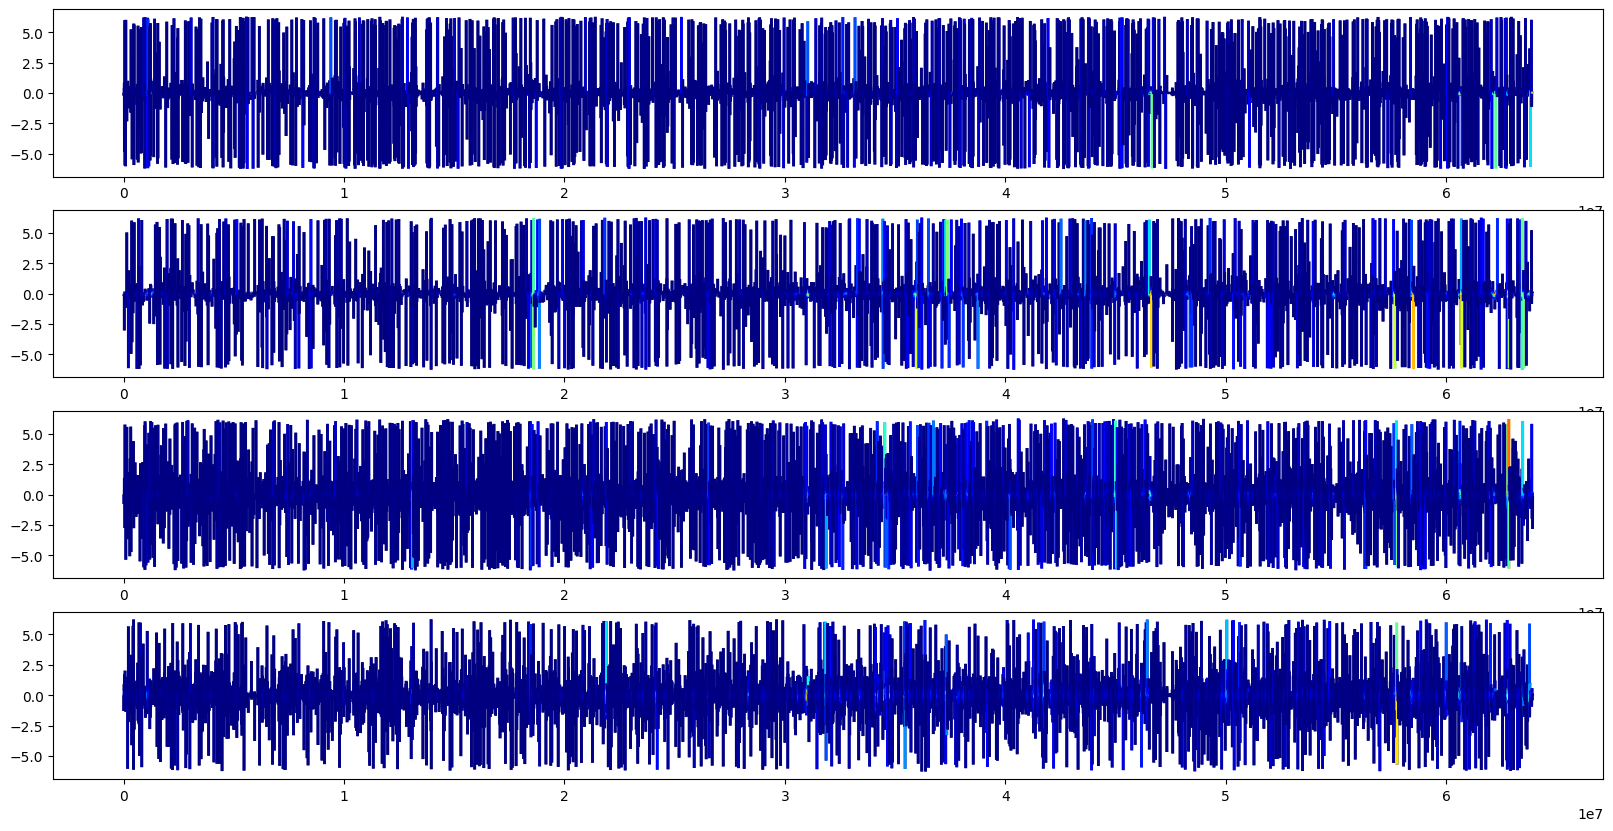

In [244]:
fig, axs = plt.subplots(4, 1, figsize=(20, 10))
plot_multicolored(axs[0], instantAngle.index, instantAngle[0],test[0].pow(2) )
plot_multicolored(axs[1], instantAngle.index, instantAngle[1],test[1].pow(2) )
plot_multicolored(axs[2], instantAngle.index, instantAngle[2],test[2].pow(2) )
plot_multicolored(axs[3], instantAngle.index, instantAngle[3],test[3].pow(2) )

In [ ]:
import matplotlib.dates as mdates

# Verificar o major locator (define onde os ticks aparecem)
print("Major Locator:", axs[0].xaxis.get_major_locator())

# Verificar o minor locator (para ticks menores, se houver)
print("Minor Locator:", axs[0].xaxis.get_minor_locator())

# Verificar o formatter (formato dos rótulos das datas)
print("Formatter:", axs[0].xaxis.get_major_formatter())

print("Tick positions:", axs[0].get_xticks())  # Mostra as coordenadas dos ticks
print("Tick labels:", [tick.get_text() for tick in ax.get_xticklabels()])  # Mostra os textos nos ticks

print("X-axis limits:", ax.get_xlim())

print("Tick label rotation:", ax.xaxis.get_tick_params())


Major Locator: <pandas.plotting._matplotlib.converter.TimeSeries_DateLocator object at 0x7f8e10a14b00>
Minor Locator: <pandas.plotting._matplotlib.converter.TimeSeries_DateLocator object at 0x7f8e10a625d0>
Formatter: <pandas.plotting._matplotlib.converter.TimeSeries_DateFormatter object at 0x7f8e0bcceff0>
Tick positions: [362883 363024 363744 364488 365232 365952 366458]
Tick labels: ['−2', '0', '2', '4', '6', '8', '10', '12']
X-axis limits: (np.float64(-0.5), np.float64(10.5))
Tick label rotation: {'bottom': True, 'top': False, 'labelbottom': True, 'labeltop': False, 'gridOn': False}
